<a href="https://colab.research.google.com/github/mkg6573/social_media_impact_on_life_ml_/blob/main/Unsupervised%20Learning/K_Means__Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/Social_media_impact_on_life_Clean_Dataset.csv")
df.head()

,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,21,Male,Undergraduate,4.0,Facebook,No,6.7,6.8,Neutral
1,23,Female,Undergraduate,1.6,LinkedIn,No,8.6,7.6,Positive
2,22,Male,Graduate,4.6,Instagram,No,6.7,7.0,Neutral
3,18,Male,Undergraduate,7.0,Snapchat,Yes,5.4,5.3,Negative
4,24,Female,High School,7.5,Facebook,Yes,5.0,4.4,Negative


In [11]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score'],
      dtype='object')

In [4]:
X = df[num_cols]

In [5]:
preprocessor = Pipeline(steps=[
    ('scaler', StandardScaler())
])

X_processed = preprocessor.fit_transform(X)

Find Best Value of K (Elbow Method)

In [6]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X_processed)

    wcss.append(kmeans.inertia_)

Plot Elbow Graph

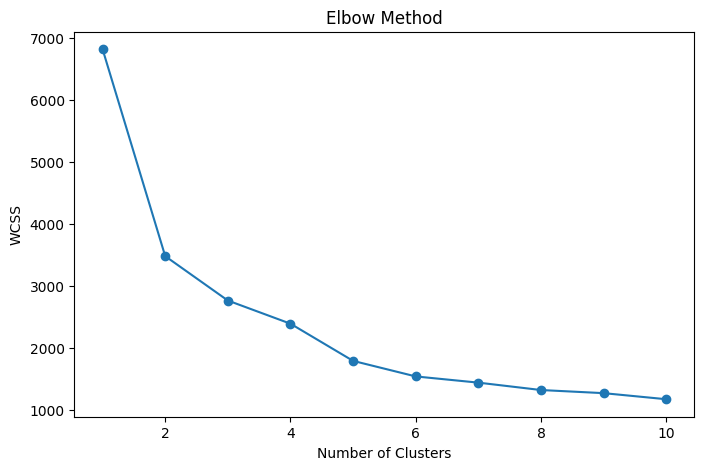

In [7]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

Apply K-Means

In [8]:
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42
)

clusters = kmeans.fit_predict(X_processed)

Visualize Clusters

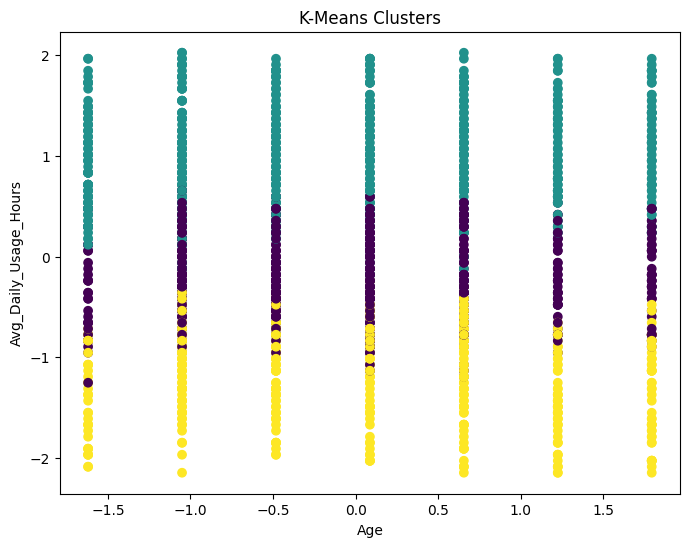

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_processed[:,0],
    X_processed[:,1],
    c=clusters,
    cmap='viridis'
)

plt.xlabel(num_cols[0])
plt.ylabel(num_cols[1])

plt.title("K-Means Clusters")

plt.show()